<a href="https://colab.research.google.com/github/lynnkaram/ml-course-projects/blob/main/project-2-deep-learning-and-gaussian-processes/deep_learning_gaussian_processes_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Intermediate Machine Learning: Assignment 2

**Deadline**

Assignment 2 is due Thursday, October  9 by 11:59 pm. Late work will not be accepted as per the course policies (see the syllabus on Canvas).

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. Acknowledge any use of an AI system such as ChatGPT or Copilot.

You should start early so that you have time to get help if you're stuck. The drop-in office hours schedule can be found on Canvas. You can also post questions or start discussions on Ed Discussion. The assignment may look long at first glance, but the problems are broken up into steps that should help you to make steady progress.

**Submission**

Submit your assignment as a .pdf on Gradescope. To convert your notebook to a .pdf while preserving the cell structure without truncating the output, you can convert to .html using [this notebook](https://colab.research.google.com/github/YData123/sds365-fa25/blob/main/assignments/Convert_ipynb_to_HTML_in_Colab.ipynb). Note: When submitting on Gradescope, please select the correct pages of your pdf that correspond to each problem. This will allow graders to more easily find your complete solution to each problem.

**Topics**

 * Convolutional neural nets
 * Gaussian processes
 * Double descent

Please note that while the problems may look long, we give you substantial starter code to make the work manageable. The course staff members are available to help during office hours!

**Acknowledgement**

I acknowledge the use of ChatGPT and Claude as a tool to help write and debug some of the codes in this assignment.
I acknowledge the use of demo codes and lecture slides for the rest.

## Problem 1: Dilation elation (35 points)

### Overview

A dilated convolution (also known as atrous convolution) inserts gaps between kernel entries, so that a $k \times k$ filter “jumps” by a dilation rate $𝑑$. A dilation rate of $d=1$ is the regular convolution. CNN dilation can be adjusted using parameter $d$ as shown in the figure below.  



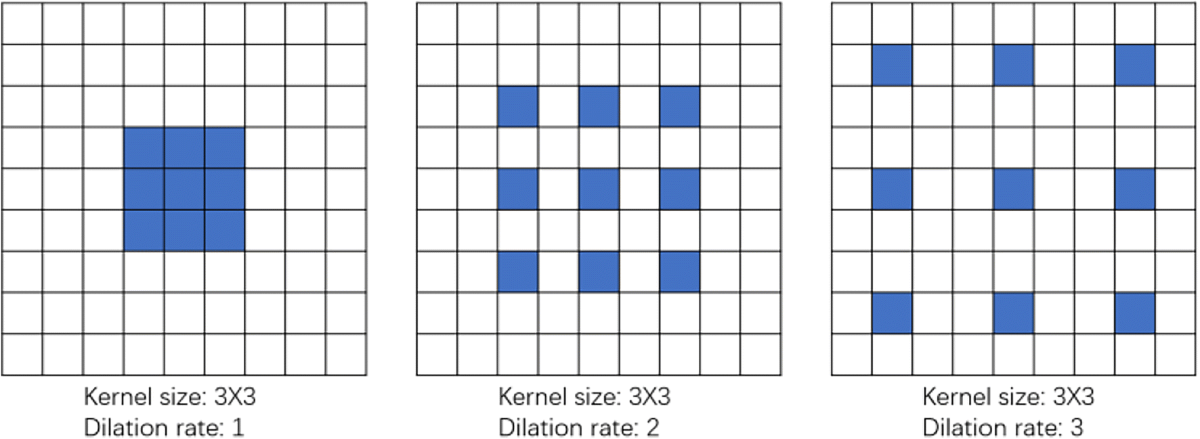




Dilated convolution captures a wider area of the input, allowing for potentially better context modeling without increased computational cost. It expands the effective "receptive field" (the area of the filter) without the need for larger kernels or more model parameters; dilated convolution can also reduce blurring. One of the most successful uses of  dilated convolution was in the first AlphaFold paper, one of the earliest CNN-based attempts to predict the structure of proteins. For a glimpse of the full architecture and its details you may wish to take a look at https://www.nature.com/articles/s41586-019-1923-7

In this problem, we use dilated convolution to analyze MRI images to detect the presence of certain types of brain tumors. Cues about tumor type can include texture information (enhanced rim, necrotic core) and global characteristics (edema extent, mass effect, midline shift). Dilation expands the effective receptive field while keeping high-resolution features available for downstream neural network layers that make the multi-class decision. This approach is also helps address the problem of "anisotropy" where some characteristics are directionally dependent, by trying to incorporate a larger sub image in the kernel.

In the first part of this problem, we implement a regular CNN. Then, your job will be to implement a dilated CNN, and to choose the dilation parameters so that the model is as accurate as you can make it.  Finally, we use Monte Carlo dropout as a way to estimate the uncertainty in the predictions.

### Dilated convolution in one and two dimensions

**Symbols (what each letter means):**
- $x$: the **input** (a 1D signal for the first formula; a 2D image for the second).
- $y$: the **output feature map** after convolution (same shape type as $x$).
- $w \in \mathbb{R}^{k}$: a 1D **kernel/filter** of length $k$.
- $W \in \mathbb{R}^{k\times k}$: a 2D **kernel/filter** of size $k \times k$.
- $k$: **kernel size** (e.g., $k=3$ for a $3\times3$ kernel).
- $d$: **dilation rate** (how far apart the kernel taps are; $d=1$ is a standard convolution).
- $i,j$: spatial **indices** of the output $y$ (row/column).
- $m,u,v$: **indices inside the kernel** (1D: $m$, 2D: $u$ for rows, $v$ for cols).
- $u_c=\lfloor k/2\rfloor$, $v_c=\lfloor k/2\rfloor$: the **kernel center** offsets (so the kernel is centered).
- We assume **stride $=1$** and appropriate padding so indices are valid.


---
---


**1D dilated convolution** of a signal $x$ with kernel $w \in \mathbb{R}^{k}$ and dilation $d \in \mathbb{N}$:
$$
y[i] \;=\; \sum_{m=0}^{k-1} w[m]\; x\!\bigl(i + d\,m\bigr).
$$

**2D dilated convolution** of an image $x$ with kernel $W \in \mathbb{R}^{k\times k}$ and dilation $d$ (stride $1$).  
Let $u_c=\lfloor k/2\rfloor$ and $v_c=\lfloor k/2\rfloor$ denote the kernel center:
$$
y[i,j] \;=\; \sum_{u=0}^{k-1}\sum_{v=0}^{k-1}
W[u,v]\; x\!\bigl(i + d\,(u-u_c),\; j + d\,(v-v_c)\bigr).
$$

**Effective receptive field** of a $k\times k$ kernel with dilation $d$:
$$
k_{\text{eff}} \;=\; k + (k-1)\,(d-1).
$$

For example, for $k=3$ and $d=3$, we get $k_{\text{eff}}=7$.  
(When $d=1$, this reduces to the standard convolution.)

### Loading the MRI data

The data used in this problem is cropped from this Kaggle repository https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset.

We only use the data corresponding to glioma tumors and non-tumor images. You can access the data in a zip file at [https://github.com/YData123/sds365-fa25/tree/main/assignments/assn2/](https://github.com/YData123/sds365-fa25/tree/main/assignments/assn2/).
You will need to upload the data to your Google Drive.

The cell below gives Colab access to your Google Drive.


In [ ]:
# Please do not edit this cell.
# Imports
import os, random, time, math, keras, json
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import layers as L, models as M

# (Colab) Mount Google Drive
from google.colab import drive
if not os.path.ismount("/content/drive"):
  drive.mount("/content/drive")

Mounted at /content/drive


Now that we mounted Google Drive let's try visualizing images in the training data for the tumor and non-tumor classes.

In [ ]:
# Do not edit this block.
# Point to the MRI/ folder that contains Training/ and Testing/
ROOT = "/content/drive/MyDrive/MRI/kaggle-MRI"

TRAIN_DIR = os.path.join(ROOT, "Training")
TEST_DIR  = os.path.join(ROOT, "Testing")
CLASS_NAMES = ["glioma", "notumor"]  # expected two folders inside both training/ and testing/

# Validation of directory structure
def assert_dir(p):
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Expected directory not found: {p}")

assert_dir(ROOT)
assert_dir(TRAIN_DIR)
assert_dir(TEST_DIR)

# Load image as grayscale for consistent viewing
def load_img_gray(path):
    img = Image.open(path).convert("L")  # force grayscale
    return img

# List image files in a folder
def count_images(folder):
    exts = ("*.jpg", "*.jpeg")
    files = []
    for e in exts:
        files.extend(glob(os.path.join(folder, e)))
    return sorted(files)

The data we have requires pre-processing in order to be fed to any neural networks. The inconsistencies in the size as you see in the above output becomes problematic during feeding the data to the network. In this block, we strive to solve that issue.

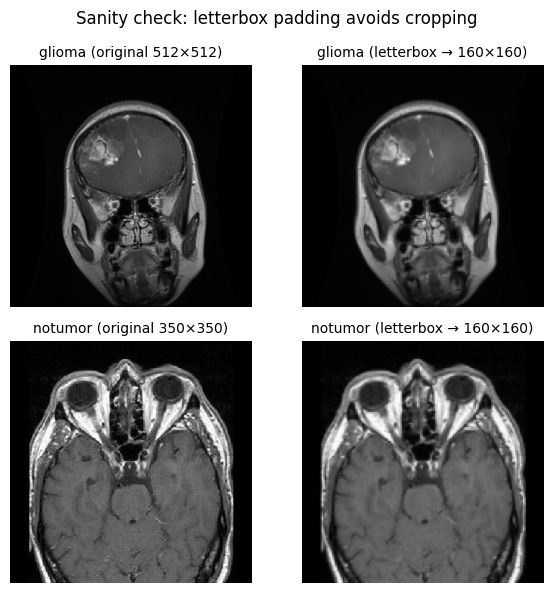

In [ ]:
# Helper functions: letterbox pad to square (no cropping) + resize to 160x160

IMG_SIZE = 160  # target size used throughout the assignment

def letterbox_to_square(img: Image.Image, fill=0) -> Image.Image:
    """
    Pads the image to a square using 'fill' (black), centered, without distortion.
    Keeps original content intact (no cropping).
    """
    if img.mode not in ("L", "RGB"):
        img = img.convert("L")
    w, h = img.size
    s = max(w, h)
    canvas = Image.new(img.mode, (s, s), color=fill)
    canvas.paste(img, ((s - w)//2, (s - h)//2))
    return canvas

def preprocess_image(img: Image.Image, size: int = IMG_SIZE) -> Image.Image:
    """Letterbox pad -> resize to (size, size)."""
    sq = letterbox_to_square(img, fill=0)
    return sq.resize((size, size), resample=Image.BILINEAR)

# Visualize ORIGINAL vs PREPROCESSED (letterboxed) for first training image of each class
fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(6, 3*len(CLASS_NAMES)))
if len(CLASS_NAMES) == 1:
    axes = np.array([axes])  # ensure 2D array indexing

for i, c in enumerate(CLASS_NAMES):
    class_dir = os.path.join(TRAIN_DIR, c)
    files = count_images(class_dir)
    ax_orig, ax_proc = axes[i, 0], axes[i, 1]
    if not files:
        ax_orig.axis("off"); ax_proc.axis("off")
        ax_proc.set_title(f"No images found for {c}")
        continue

    p = files[0]
    img = load_img_gray(p)            # original grayscale
    proc = preprocess_image(img)      # padded + resized 160x160

    ax_orig.imshow(img, cmap="gray");  ax_orig.axis("off")
    ax_orig.set_title(f"{c} (original {img.size[0]}×{img.size[1]})", fontsize=10)

    ax_proc.imshow(proc, cmap="gray"); ax_proc.axis("off")
    ax_proc.set_title(f"{c} (letterbox → {IMG_SIZE}×{IMG_SIZE})", fontsize=10)

plt.suptitle("Sanity check: letterbox padding avoids cropping", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Gather file paths & labels; split TRAIN into train/validation (TEST untouched)

def list_images_with_labels(root_dir, classes):
    paths, labels = [], []
    for ci, cname in enumerate(classes):
        cdir = os.path.join(root_dir, cname)
        for p in count_images(cdir):
            paths.append(p); labels.append(ci)
    return np.array(paths), np.array(labels)

# load TRAIN and TEST file lists
train_paths, train_labels = list_images_with_labels(TRAIN_DIR, CLASS_NAMES)
test_paths,  test_labels  = list_images_with_labels(TEST_DIR,  CLASS_NAMES)

# stratified split of TRAIN -> (train, val)
VAL_FRACTION = 0.20
tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=VAL_FRACTION,
    random_state=42,
    stratify=train_labels
)

print(f"Counts -> train: {len(tr_paths)}, val: {len(val_paths)}, test: {len(test_paths)}")

Counts -> train: 2332, val: 584, test: 705


In [ ]:
# TensorFlow input pipeline with the SAME preprocessing:
# grayscale -> letterbox to square (no crop) -> resize to IMG_SIZE -> per-image z-score

def tf_letterbox_resize(img, target=IMG_SIZE):
    shape = tf.shape(img)
    h, w = shape[0], shape[1]
    s = tf.maximum(h, w)
    pad_top  = (s - h) // 2
    pad_bottom = s - h - pad_top
    pad_left = (s - w) // 2
    pad_right = s - w - pad_left
    img_sq = tf.pad(img, [[pad_top, pad_bottom],[pad_left, pad_right],[0,0]], mode="CONSTANT", constant_values=0.0)
    img_rs = tf.image.resize(img_sq, (target, target), method="bilinear")
    return img_rs

def tf_per_image_zscore(img):
    mean = tf.reduce_mean(img)
    std  = tf.math.reduce_std(img)
    return (img - mean) / tf.maximum(std, 1e-6)

def load_and_preprocess(path, label, augment=False):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=1, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf_letterbox_resize(img, target=IMG_SIZE)

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.10)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)

    img = tf_per_image_zscore(img)
    label = tf.cast(label, tf.float32)
    label = tf.expand_dims(label, axis=-1)   # (1,)
    return img, label

def make_dataset(paths, labels, batch_size=32, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_and_preprocess(p, y, augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 16
ds_train = make_dataset(tr_paths,  tr_labels,  batch_size=BATCH_SIZE, shuffle=True,  augment=True)
ds_val   = make_dataset(val_paths, val_labels, batch_size=BATCH_SIZE, shuffle=False, augment=False)
ds_test  = make_dataset(test_paths, test_labels, batch_size=BATCH_SIZE, shuffle=False, augment=False)

for xb, yb in ds_train.take(1):
    print("Train batch:", xb.shape, yb.shape)

Train batch: (16, 160, 160, 1) (16, 1)


/tmp/ipython-input-1886849759.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = int(yb[i])


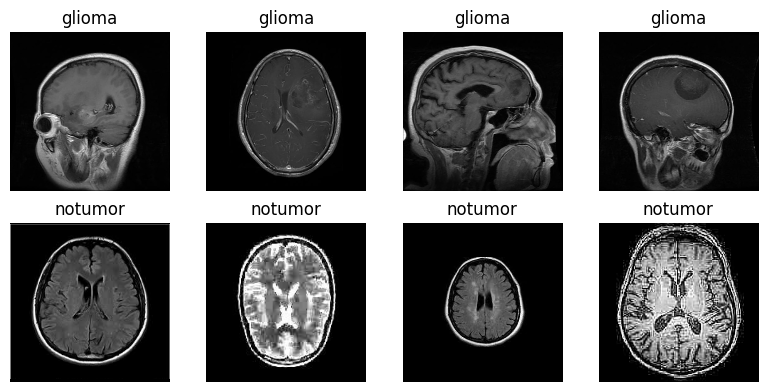

In [ ]:
# Quick visual sanity check: Show 4 preprocessed samples per class from the TRAIN pipeline
class_names = CLASS_NAMES

# collect a small batch
xb, yb = next(iter(ds_train))
xb = xb.numpy(); yb = yb.numpy()

fig, axes = plt.subplots(2, 4, figsize=(8,4))
axes = axes.reshape(-1)
shown = {i:0 for i in range(len(class_names))}
for i in range(len(xb)):
    c = int(yb[i])
    if shown[c] >= 4:
        continue
    axes[c*4 + shown[c]].imshow(xb[i,...,0], cmap="gray")
    axes[c*4 + shown[c]].axis("off")
    axes[c*4 + shown[c]].set_title(class_names[c])
    shown[c]+=1
    if all(v==4 for v in shown.values()):
        break
plt.tight_layout(); plt.show()

In [ ]:
"""
You'll learn two new layers in this assignment. MCSpatialDropout2D is a smarter type of dropout for image processing
networks. Instead of randomly turning off individual pixels, it turns off entire channels (feature detectors) all at
once. This works better for images because it prevents the network from getting too dependent on specific feature
detectors working together, which helps it generalize better to new data. BatchNormalization helps keep your network's
internal signals stable during training. It takes the outputs from each layer and normalizes them (resembling standardizing
data), then applies two learnable parameters to scale and shift the results as needed. This makes training more stable and
often lets you use higher learning rates, leading to faster and more reliable training.
"""
# Keras model factory: Build a baseline CNN
# Force-dropout layers that stay active at inference for MC sampling (BatchNorm stays frozen)
@keras.saving.register_keras_serializable(package="mc")
class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        # Force sampling masks even at inference for MC passes
        return super().call(inputs, training=True)

@keras.saving.register_keras_serializable(package="mc")
class MCSpatialDropout2D(tf.keras.layers.SpatialDropout2D):
    def call(self, inputs, training=None):
        # Force sampling masks even at inference for MC passes
        return super().call(inputs, training=True)

def build_cnn(
    dilated=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 1),
    num_classes=1,                # 1 sigmoid unit (binary)
    drop_rate=0.20,
    use_mc_dropout=True,          # if True, use MC* layers; else standard Dropout
    use_spatial=True              # SpatialDropout2D is usually better for convs
):
    """
    Tiny CNN; toggle dilation in block-2 convs. Adds dropout so MC sampling works.
    - dilated=False: Conv3x3 (rate=1)
    - dilated=True : dilation rates (2,3,5) in the 2nd conv of each block
    - Dropout: after each block; optionally before Dense head
    """
    rates = (1,1,1)

    Drop = (MCSpatialDropout2D if (use_mc_dropout and use_spatial) else
            L.SpatialDropout2D if use_spatial else
            MCDropout if use_mc_dropout else
            L.Dropout)

    x_in = L.Input(shape=input_shape)
    x = x_in

    # Block A
    x = L.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(32, 3, padding="same", activation="relu", dilation_rate=rates[0])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    # Block B
    x = L.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(64, 3, padding="same", activation="relu", dilation_rate=rates[1])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    # Block C
    x = L.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(128, 3, padding="same", activation="relu", dilation_rate=rates[2])(x)
    x = L.BatchNormalization()(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = L.Dropout(drop_rate)(x)  # a small dense-level dropout is fine (standard)

    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)  # binary head
    model = tf.keras.Model(x_in, out)
    return model

# Rebuild models (students then train as in Step 14)
model_base = build_cnn(dilated=False)
model_base.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d            │ (None, 80, 80, 32)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_1          │ (None, 40, 40, 64)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_2          │ (None, 40, 40, 128)    │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             

 Total params: 288,353 (1.10 MB)

 Trainable params: 287,457 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

### Problem 1.1: Explain the CNN

The cell above shows layer of the CNN, with the output tensor shape and the number of trainable parameters. For each layer, explain in a couple of sentences (1) what the purpose of the layer is (2) why the output shape and number of parameters are as shown.

#### Markdown:

**input_layer (InputLayer)**

(1) The purpose of this layer is to specify that the model will take grayscale images ("1") with a resolution of 160 x 160 pixels as input, hence the (160, 160, 1)

(2) It has no parameters ("0") because it only defines the expected data shape and does not perform any learning. "None" represents the batch size.

**conv2d (Conv2D)**

(1) This layer learns 32 filters that scan across the image to detect simple local features like edges, corners, and textures.

(2) The output (None, 160, 160, 32) maintains spatial dimensions due to "same" padding while creating 32 feature maps. It has 320 parameters calculated as (3 x 3 kernel x 1 input channel + 1 bias) x 32 filters = 320.

**batch_normalization (BatchNormalization)**

(1) The purpose of this layer is to normalize the the activations from the previous layer to have mean 0 and variance 1 so that the training remains stable and convergence is faster.

(2) It introduces two trainable parameters per channel (scale and shift) along with two non-trainable statistics (mean and variance), giving four values per channel and for 32 channels, a total of 32 gamma (scale) + 32 beta (shift) + 32 moving mean + 32 moving variance = 128.

**conv2d_1 (Conv2D)**

(1) This layer is the second convolutional layer in Block A that learns more complex combinations of the features detected by the first convolutional layer, using 32 filters. It extracts more complex patterns from the initial feature maps and allows the network to combine edges into shapes and textures.

(2) The output (None, 160, 160, 32) again maintains dimensions. It has (3 x 3 kernel x 32 input channels + 1 bias) x 32 filters = 9,248 parameters.

**batch_normalization_1 (BatchNormalization)**

(1) The purpose here is to normalize activations after the second convolution. It keeps the distributions of feature values consistent after convolution, which reduces sensitivity to both initialization and learning rate.

(2) Again for 32 channels, there are 128 total parameters (following the same calculation as above).

**max_pooling2d (MaxPooling2D)**

(1) This layer downsamples the feature maps by taking the maximum value in each 2 x 2 window, which reduces spatial resolution while keeping strong features.

(2) The output (None, 80, 80, 32) halves height and width. It has 0 parameters since max pooling is a fixed operation with no learnable weights.

**mc_spatial_dropout2d (MCSpatialDropout2D)**

(1) The purpose of this layer is to prevent overfitting by randomly turning off entire feature maps during training. This forces the model to rely on multiple detectors.

(2) It has no parameters because it only drops activations and does not store weights.

**conv2d_2 (Conv2D)**

(1) This is the first convolution in Block B. It detects more detailed and mid-level features by applying double the number of channels so 64 different 3 x 3 filters to the 32 input feature maps.

(2) The parameters are 3 x 3 x 32 x 64 weights plus 64 biases = 18,496 in total.

**batch_normalization_2 (BatchNormalization)**

(1) This layer ensures that the 64 channels remain normalized to maintain stable activations.

(2) 4 values per channel so the parameter count is 64 x 4 = 256 total parameters.

**conv2d_3 (Conv2D)**

(1) This second convolution in block B, it refines the mid-level features by allowing interactions between the 64 feature maps.

(2) The calculation is 3 x 3 x 64 x 64 weights + 64 biases = 36,928 total parameters.

**batch_normalization_3 (BatchNormalization)**

(1) The purpose here is to stabilize training before pooling and dropout and make optimization easier after another convolutional transformation.

(2) It has 256 parameters because there are 64 channels with 4 values each.

**max_pooling2d_1 (MaxPooling2D)**

(1) This pooling step reduces the spatial size by 2, to 40 x 40. It condenses the feature maps and lowers computation cost.

(2) It has zero parameters simply because no weights are learned in pooling operations.

**mc_spatial_dropout2d_1 (MCSpatialDropout2D)**

(1) This dropout layer improves generalization by forcing the network not to depend too heavily on specific channels.

(2) It adds no parameters since it only modifies the activation outputs stochastically.

**conv2d_4 (Conv2D)**

(1) This layer expands the representation to 128 feature maps, which enables the model to capture high-level structures such as shapes or textures.

(2) Its total number of parameters are 3 x 3 x 64 x 128 weights + 128 biases = 73,856.

**batch_normalization_4 (BatchNormalization)**

(1) This layer stabilizes the deeper network, it keeps feature values within a controlled range.

(2) 128 channels x 4 parameters each = total of 512.

**conv2d_5 (Conv2D)**

(1) Again, this layer extracts even more complex combinations of high-level features by connecting 128 input maps to 128 output maps.

(2) The calculation is 3 x 3 x 128 x 128 weights + 128 biases = 147,584 total parameters.

**batch_normalization_5 (BatchNormalization)**

(1) This layer normalizes the final convolutional outputs to make them easier for the classifier to use.

(2) Again for 128 channels --> 512 parameters.

**mc_spatial_dropout2d_2 (MCSpatialDropout2D)**

(1) Again, this dropout regularization step ensures that the model does not overfit by relying too much on specific high-level channels.

(2) It has no parameters because it only applies random dropping during training.

**global_average_pooling2d  (Global Average Pooling2D)**

(1) This layer compresses each 40 x 40 feature map into a single value by averaging. It turns the spatial information into a compact vector of 128 elements.

(2) It adds no parameters since it only computes averages across each map.

**dropout (Dropout)**

(1) The purpose here is to improve generalization by randomly zeroing out some of the 128 features before the final layer. It helps prevent overfitting in the classification head.

(2) It does not contribute parameters because dropout does not learn weights.

**dense (Dense)**

(1) This layer produces the final binary classification by mapping the 128 features to a single probability between 0 and 1. It does that using the sigmoid activation function which maps a probability value to a binary classification of 0 (no cancer) or 1 (cancer).

(2) The parameter count comes from 128 weights (one for each feature) + 1 bias = 129.

The following cell now trains the baseline CNN, and evaluates it on test data.

In [ ]:
# Train the baseline model (with validation) + evaluate on TEST + plots

EPOCHS  = 10
OUTDIR  = "/content/outputs_cnn_dilation"
os.makedirs(OUTDIR, exist_ok=True)

def compile_model(m):
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-5),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)])
    return m

def train_model(model, name, train_ds, val_ds, epochs=EPOCHS):
    ckpt = os.path.join(OUTDIR, f"{name}.keras")  # best checkpoint
    cbs = [ModelCheckpoint(ckpt, monitor="val_accuracy", save_best_only=True, verbose=1)]
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cbs, verbose=1)
    train_seconds = time.time() - t0
    print(f"[TIMER] {name}: training wall-clock = {train_seconds:.2f} sec "
          f"({train_seconds/max(1,len(hist.history['loss'])):.2f} sec/epoch) (monitoring val_accuracy)")
    # OPTIONAL: save the final weights separately (do NOT overwrite ckpt)
    final_path = os.path.join(OUTDIR, f"{name}_final.keras")
    model.save(final_path)
    return ckpt, hist, train_seconds

def evaluate_and_report(model, ds, class_names):
    y_true, y_pred = [], []
    out_last_dim = model.output_shape[-1]  # 1 for sigmoid, 2 for softmax
    for xb, yb in ds:
        probs = model.predict(xb, verbose=0)
        probs = np.array(probs).reshape((probs.shape[0], -1))
        preds = (probs[:,0] >= 0.5).astype(int) if out_last_dim == 1 else np.argmax(probs, axis=1)
        yt = yb.numpy().reshape(-1).astype(int)
        y_true.append(yt); y_pred.append(preds)
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    return y_true, y_pred

def measure_eval_time(model, ds, n_samples):
    t0 = time.time()
    loss, acc = model.evaluate(ds, verbose=0)
    eval_seconds = time.time() - t0
    print(f"[TIMER] evaluate: {eval_seconds:.2f} sec")
    t1 = time.time()
    _ = model.predict(ds, verbose=0)
    pred_seconds = time.time() - t1
    ips = n_samples / pred_seconds if pred_seconds > 0 else float("inf")
    print(f"[TIMER] predict : {pred_seconds:.2f} sec  (~{ips:.1f} images/sec)")
    return loss, acc, eval_seconds, pred_seconds, ips

# --- compile
model_base = compile_model(model_base)

# --- train with validation (no test leakage)
ckpt_base, hist_base, train_time_base = train_model(model_base, "baseline_cnn", ds_train, ds_val, epochs=EPOCHS)

# --- reload best and evaluate on TEST (timed)
model_base = tf.keras.models.load_model(ckpt_base)

print("\n[TEST] Baseline:")
y_true_base, y_pred_base = evaluate_and_report(model_base, ds_test, CLASS_NAMES)
loss_b, acc_b, eval_t_b, pred_t_b, ips_b = measure_eval_time(model_base, ds_test, n_samples=len(test_paths))

print(f"\n[TEST] Baseline -> loss: {loss_b:.4f} | acc: {acc_b:.4f}")



Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6219 - loss: 0.6487
Epoch 1: val_accuracy improved from -inf to 0.45377, saving model to /content/outputs_cnn_dilation/baseline_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 616s 4s/step - accuracy: 0.6222 - loss: 0.6484 - val_accuracy: 0.4538 - val_loss: 1.0562
Epoch 2/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7227 - loss: 0.5573
Epoch 2: val_accuracy improved from 0.45377 to 0.45548, saving model to /content/outputs_cnn_dilation/baseline_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 599s 4s/step - accuracy: 0.7228 - loss: 0.5572 - val_accuracy: 0.4555 - val_loss: 1.0277
Epoch 3/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7634 - loss: 0.5006
Epoch 3: val_accuracy improved from 0.45548 to 0.59932, saving model to /content/outputs_cnn_dilation/baseline_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 596s 4s/step - accuracy: 0.7635 - loss: 0.5004 - val_accuracy: 0.5993 - val_loss: 0.6863
Epoch 4/10
146/146 ━━━━━━━━━━━━

### Problem 1.2: Improve on the baseline with a dilated CNN

Your job is now to use the above code, appropriately modified as needed, to build and train a dilated CNN that has better accuracy than the baseline.

Note that the keras Conv2D method can handle dilation. You may experiment with any architecture (combination of layers) and dilation parameters that you wish.

To keep the notebook clear, only show your best model, not intermediate, experimental models. Explain your choice of model, and why your best dilation CNN model does or does not improve on the baseline. Note that you should use a runtime environment that uses a GPU for faster processing speed.

In [ ]:
# Dilated CNN to improve baseline

@keras.saving.register_keras_serializable(package="mc")
class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

@keras.saving.register_keras_serializable(package="mc")
class MCSpatialDropout2D(tf.keras.layers.SpatialDropout2D):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

def build_cnn(
    input_shape=(IMG_SIZE, IMG_SIZE, 1),  # I deleted the "dialated = True/False" part to make it less confusing
    num_classes=1,
    drop_rate=0.20, # tried changing these to 0.25 and 0.15 but wasn't getting good results so left it at 0.20
    use_mc_dropout=True,
    use_spatial=True
):
    rates = (2, 3, 5) #changed the rates from 1,1,1 to these (as was "hinted" in the comments of the baseline code)

    Drop = (MCSpatialDropout2D if (use_mc_dropout and use_spatial) else
            L.SpatialDropout2D if use_spatial else
            MCDropout if use_mc_dropout else
            L.Dropout)

    x_in = L.Input(shape=input_shape)
    x = x_in

    # Block A
    x = L.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(32, 3, padding="same", activation="relu", dilation_rate=rates[0])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)

    # Block B
    x = L.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(64, 3, padding="same", activation="relu", dilation_rate=rates[1])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)

    # Block C
    x = L.Conv2D(128, 3, padding="same", activation="relu", dilation_rate = 2)(x) #and just added this additional dilation = 2 in this block
    x = L.BatchNormalization()(x)
    x = L.Conv2D(128, 3, padding="same", activation="relu", dilation_rate=rates[2])(x)
    x = L.BatchNormalization()(x)
    x = Drop(drop_rate)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = L.Dropout(drop_rate)(x)

    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(x_in, out)
    return model

# Rebuild models (students then train as in Step 14)
model_dil = build_cnn()
model_dil.summary()



Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_9          │ (None, 80, 80, 32)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_10         │ (None, 40, 40, 64)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_11         │ (None, 40, 40, 128)    │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             

 Total params: 288,353 (1.10 MB)

 Trainable params: 287,457 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Train the new model (with validation) + evaluate on TEST + plots
EPOCHS  = 10 #also changed epochs from 10 to 20 to give the dilated model more time to converge
OUTDIR  = "/content/outputs_cnn_dilation"
os.makedirs(OUTDIR, exist_ok=True)

# redefine everything so I don't need to run the baseline every time
def compile_model(m):
    m.compile(
        optimizer=tf.keras.optimizers.Adam(3e-5),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
        metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)]
    )
    return m

def train_model(model, name, train_ds, val_ds, epochs=EPOCHS):
    ckpt = os.path.join(OUTDIR, f"{name}.keras")  # best checkpoint
    cbs = [ModelCheckpoint(ckpt, monitor="val_accuracy", save_best_only=True, verbose=1)]
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cbs, verbose=1)
    train_seconds = time.time() - t0
    print(f"[TIMER] {name}: training wall-clock = {train_seconds:.2f} sec "
          f"({train_seconds/max(1,len(hist.history['loss'])):.2f} sec/epoch) (monitoring val_accuracy)")
    # OPTIONAL: save final (don’t overwrite ckpt)
    model.save(os.path.join(OUTDIR, f"{name}_final.keras"))
    return ckpt, hist, train_seconds

def evaluate_and_report(model, ds, class_names):
    y_true, y_pred = [], []
    out_last_dim = model.output_shape[-1]  # 1 for sigmoid, 2 for softmax
    for xb, yb in ds:
        probs = model.predict(xb, verbose=0)
        probs = np.array(probs).reshape((probs.shape[0], -1))
        preds = (probs[:,0] >= 0.5).astype(int) if out_last_dim == 1 else np.argmax(probs, axis=1)
        yt = yb.numpy().reshape(-1).astype(int)
        y_true.append(yt); y_pred.append(preds)
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    return y_true, y_pred

def measure_eval_time(model, ds, n_samples):
    t0 = time.time()
    loss, acc = model.evaluate(ds, verbose=0)
    eval_seconds = time.time() - t0
    print(f"[TIMER] evaluate: {eval_seconds:.2f} sec")
    t1 = time.time()
    _ = model.predict(ds, verbose=0)
    pred_seconds = time.time() - t1
    ips = n_samples / pred_seconds if pred_seconds > 0 else float("inf")
    print(f"[TIMER] predict : {pred_seconds:.2f} sec  (~{ips:.1f} images/sec)")
    return loss, acc, eval_seconds, pred_seconds, ips

model_dil = build_cnn()           # use build_cnn defined above with rates=(2,3,5). change False to True.
model_dil = compile_model(model_dil)

# train with validation and test
ckpt_dil, hist_dil, train_time_dil = train_model(model_dil, "dilated_cnn", ds_train, ds_val, epochs=EPOCHS)
model_dil = tf.keras.models.load_model(ckpt_dil)

print("\n[TEST] Dilated:")
y_true_dil, y_pred_dil = evaluate_and_report(model_dil, ds_test, CLASS_NAMES)
loss_d, acc_d, eval_t_d, pred_t_d, ips_d = measure_eval_time(model_dil, ds_test, n_samples=len(test_paths))
print(f"\n[TEST] Dilated -> loss: {loss_d:.4f} | acc: {acc_d:.4f}")

Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6289 - loss: 0.6321
Epoch 1: val_accuracy improved from -inf to 0.45377, saving model to /content/outputs_cnn_dilation/dilated_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 818s 6s/step - accuracy: 0.6293 - loss: 0.6317 - val_accuracy: 0.4538 - val_loss: 1.2275
Epoch 2/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7643 - loss: 0.5002
Epoch 2: val_accuracy did not improve from 0.45377
146/146 ━━━━━━━━━━━━━━━━━━━━ 873s 6s/step - accuracy: 0.7644 - loss: 0.5000 - val_accuracy: 0.4538 - val_loss: 1.6559
Epoch 3/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8438 - loss: 0.4075
Epoch 3: val_accuracy improved from 0.45377 to 0.49658, saving model to /content/outputs_cnn_dilation/dilated_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 729s 5s/step - accuracy: 0.8438 - loss: 0.4074 - val_accuracy: 0.4966 - val_loss: 1.0685
Epoch 4/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8603 - loss: 0.3343
Epoch 4: val_accur

I modified the baseline by changing the rates from (1,1,1) to (2,3,5). Before choosing these values, I tested rates of (1,1,2), (1,2,2) and (1,2,1), which did not improve the baseline. I kept the drop rate the same after testing a higher value of 0.25 and a lower value of 0.15, as 0.20 was giving me optimal results. I added dilation = 2 on the first conv layer of block C too. In theory, increasing the epochs from 10 to 15 or 20 would also increase the performance (but also the computational time).

As for numerical comparisons, the dilated model performs better. Test accuracy increases from 0.912 (baseline) to 0.942 (dilated), and test loss drops from 0.238 to 0.175 (so -26.6%). The confusion matrix reflects the same trend: false negatives for glioma fall from 24 to 9, and false positives from 35 to 27. The main trade-off is speed, as training grows from 6062 s to 7701 s. Evaluation nearly doubles (41.5 s to 83.9 s), and prediction is modestly slower (41.0 s to 49.4 s).

Overall, using dilations rates (2,3,5) and the additional dilation of 2 in the first conv layer in block C increases the effective receptive field and yields better detection (especially higher glioma recall), but at the cost of extra compute.

### Problem 1.3 Monte Carlo dropout to assess model uncertainty

Your CNN should use Monte Carlo (MC) dropout to compute the risk at test time. For a fixed MRI image scan $x$, you obtain $T$ stochastic predictions $\{\hat y_t\}_{t=1}^T$.

<br>

**(a) Mean and variance from MC passes.**
Give mathematical expressions for the MC estimate of the predictive mean $\mu_T$ and its variance $s_T^2$ from $\{\hat y_t\}$.

*Answer*

The Monte Carlo estimate of the predictive mean $\mu_T$ is the average of the samples:
$$
\mu_T \;=\; \frac{1}{T}\sum_{t=1}^{T} \hat y_t
$$

The Monte Carlo estimate of the variance of the predictive mean $s_{T}^{2}\$ is the sample variance of the predictions (spread of stochastic predictions):
$$
s_T^2 \=\ \frac{1}{T-1}\sum_{t=1}^{T}\big(\hat y_t - \mu_T\big)^2
$$

**(b) Accuracy guarantee.**
Using Chebyshev's inequality, derive a lower bound on $T$ ensuring
$\Pr\!\big(|\mu_T-\mu_{\text{true}}|\ge \varepsilon\big)\le \delta$.
Express the minimal $T$ in terms of $\operatorname{Var}(\hat y_t)$ (or a plug-in estimate).
Clearly state any assumptions you need to make, such as Gaussianity.

*Answer*

We assume:
- The Monte Carlo predictions $\hat y_t$ for $t=1,\dots,T$ are identically distributed
- The estimators are unbiased: $\mathbb{E}[\hat y_t] = \mu_{\text{true}}$
- The variance $\operatorname{Var}(\hat y_t) = \sigma^2$ is finite

Chebyshev's inequality (for any random variable $X$ with mean $\mu$ and variance $\sigma^2$) is
$$
\Pr\!\left(|X-\mu|\ge \varepsilon\right)\;\le\;\frac{\sigma^2}{\varepsilon^2}
$$

*Reference for this: https://www.youtube.com/watch?v=otCHN3s52ho*

Consider the sample mean which we defined in part a)
$$
\mu_T \;=\; \frac{1}{T}\sum_{t=1}^{T}\hat y_t .
$$

The mean of the sample mean is
$$
\mathbb{E}[\mu_T]
= \mathbb{E}\!\left[\frac{1}{T}\sum_{t=1}^{T}\hat y_t\right]
= \frac{1}{T}\sum_{t=1}^{T}\mathbb{E}[\hat y_t]
= \mu_{\text{true}} .
$$

Its variance (using the identically distributed assumption) is
$$
\operatorname{Var}(\mu_T)
= \operatorname{Var}\!\left(\frac{1}{T}\sum_{t=1}^{T}\hat y_t\right)
= \frac{1}{T^2}\sum_{t=1}^{T}\operatorname{Var}(\hat y_t)
= \frac{T\,\sigma^2}{T^2}
= \frac{\sigma^2}{T}.
$$

Applying Chebyshev with $X=\mu_T$, $\mu=\mu_{\text{true}}$, and $\sigma^2=\operatorname{Var}(\mu_T)$:
$$
\Pr\!\left(|\mu_T-\mu_{\text{true}}|\ge \varepsilon\right)
\;\le\; \frac{\operatorname{Var}(\mu_T)}{\varepsilon^2}
\;=\; \frac{\sigma^2}{T\,\varepsilon^2}
$$


We are given the condition $\Pr\!\left(|\mu_T-\mu_{\text{true}}|\ge \varepsilon\right)\le \delta$. We can combine this with the result above that we just derived from Chebyshev's inequality, such that:
$$
\frac{\sigma^2}{T\,\varepsilon^2} \;\le\; \delta
$$

And rearranging this to find the lower bound $T$ gives:

$$
{\,T \;\ge\; \frac{\sigma^2}{\varepsilon^2\,\delta}\, }
$$

And so the the minimal $T$ in terms of $\operatorname{Var}(\hat y_t)$ (or a plug-in estimate) can be written:

Replacing the unknown $\sigma^2=\operatorname{Var}(\hat y_t)$ by the sample variance from (a),
$s_T^2=\frac{1}{T-1}\sum_{t=1}^{T}(\hat y_t-\mu_T)^2$, gives:
$$
\,T \;\ge\; \frac{s_T^2}{\varepsilon^2\,\delta}
$$

Note: This Chebyshev-based guarantee does not require Gaussianity

**(c) Numerical budget.**
With target $\varepsilon=0.05$, confidence $1-\delta=0.95$ ($\delta=0.05$), a pilot of $T_0=50$ passes giving standard deviation $s_{T_0}^2=0.08$, compute the required $T$ from part (b). Describe what this means--what guarantee does this give about the accuracy of the prediction?

*Answer*

Chebyshev requirement:
$$
T \;\ge\; \frac{\sigma^2}{\delta\,\varepsilon^2}
\;\approx\; \frac{s^2}{\delta\,\varepsilon^2}
\;=\; \frac{0.0064}{0.05 \cdot (0.05)^2}
\;=\; \frac{0.0064}{0.000125}
\;=\; 51.2
\;{T=52\ \text{passes (rounded up)}}.
$$

With regards to the guarentee, with $T=52$ MC passes,
$$
\Pr\!\left(|\mu_T - \mu_{\text{true}}| \le 0.05\right) \;\ge\; 0.95 .
$$

This means that if we take T = 52 Monte Carlo passes, then with at least 95% probability, the sample mean prediction will be within 0.05 of the true predictive mean. In other words, the chance of being off by more than 0.05 is at most 5%. This is a conservative guarantee (since Chebyshev works for any distribution with finite variance), but it provides a good numerical estimation for how many samples we need.

### Problem 1.4 Monte Carlo (MC) Dropout on test images

You will implement MC Dropout to quantify predictive uncertainty at test time. By keeping Dropout active during inference and sampling the model multiple times on the same inputs, you will approximate the posterior predictive distribution and summarize it with a mean prediction and a dispersion measure (standard deviation). Use MC Dropout to approximate the posterior predictive and quantify epistemic uncertainty at test time. Keep dropout on during inference, sample the model multiple times on the same inputs, and summarize the resulting distribution. Set the number of stochastic forward passes to a reasonable value based on the outputs you obtain. Remember by default model.predict does not keep dropout active at inference.

In this part you will:

1.   Build A sampler function that deterministically picks the first 5 images per class from the test set folder for each label (10 images in total)
2.   A stochastic inference predictive route that runs the model with dropout active and returns one probability per image in each round. Your CNN models is preferably defined as a function so that you can feed the baseline and dilated CNNs to compare the values here.
3. Calculate the mean and standard deviation of the stochastic forward passes in step 2 to generate a table or grid that depicts idices, y_true, y_hat,p_mean, p_std. The two latter values should be obtained with your stochastic forward passes with dropout on.
4. See if there is a mispredicted label based on your y_hat, then discuss the correlation between standard deviation of the stochastic runs and the final y_hat.

In [ ]:
#1. build a sampler function that deterministically picks the first 5 images per class from the test
# set folder for each label (10 images in total)
def pick_first_k_per_class(paths, class_names, k=5):
    paths = sorted(paths)  # makes it deterministic
    picked = {c: [] for c in class_names}
    for p in paths:
        cls = os.path.basename(os.path.dirname(p))
        if cls in picked and len(picked[cls]) < k:
            picked[cls].append(p)
        if all(len(picked[c]) >= k for c in class_names):
            break
    return picked

selected = pick_first_k_per_class(test_paths, CLASS_NAMES, k=5)
for cls, files in selected.items():
    print(cls, ":", files)


glioma : [np.str_('/content/drive/MyDrive/MRI/kaggle-MRI/Testing/glioma/Te-glTr_0000.jpg'), np.str_('/content/drive/MyDrive/MRI/kaggle-MRI/Testing/glioma/Te-glTr_0001.jpg'), np.str_('/content/drive/MyDrive/MRI/kaggle-MRI/Testing/glioma/Te-glTr_0002.jpg'), np.str_('/content/drive/MyDrive/MRI/kaggle-MRI/Testing/glioma/Te-glTr_0003.jpg'), np.str_('/content/drive/MyDrive/MRI/kaggle-MRI/Testing/glioma/Te-glTr_0004.jpg')]
notumor : [np.str_('/content/drive/MyDrive/MRI/kaggle-MRI/Testing/notumor/Te-noTr_0000.jpg'), np.str_('/content/drive/MyDrive/MRI/kaggle-MRI/Testing/notumor/Te-noTr_0001.jpg'), np.str_('/content/drive/MyDrive/MRI/kaggle-MRI/Testing/notumor/Te-noTr_0002.jpg'), np.str_('/content/drive/MyDrive/MRI/kaggle-MRI/Testing/notumor/Te-noTr_0003.jpg'), np.str_('/content/drive/MyDrive/MRI/kaggle-MRI/Testing/notumor/Te-noTr_0004.jpg')]


In [ ]:
# 2. A stochastic inference predictive route that runs the model with dropout active and returns one probability per image in each round.
# Your CNN models is preferably defined as a function so that you can feed the baseline and dilated CNNs to compare the values here.
def mc_predict_rounds(model, X, T=52):
    """
    inputs:
      model: the trained Keras model (baseline or dilated)
      X: batch tensor/array of shape (N, H, W, 1), where N is nb of images in batch, H is image height, W is its width, and 1 is for grayscale
      T: number of Monte Carlo passes (52 from what was solved in Chebyshev question)
    returns:
      probs_T : array of shape (T, N) --> Each row results from one run of the model
                                      --> The nbs in that row = how likely each image is glioma (from 0 to 1, via sigmoid)
    """
    outs = []
    for _ in range(T):
        p = model(X, training=True).numpy().ravel()
        outs.append(p)
    return np.stack(outs, axis=0)

In [ ]:
# 3. Calculate the mean and standard deviation of the stochastic forward passes in step 2 to generate a table or grid
# that depicts idices, y_true, y_hat,p_mean, p_std. The two latter values should be obtained with your stochastic forward passes with dropout on.
K = min(len(selected[c]) for c in CLASS_NAMES)
sel_paths = [str(p) for c in CLASS_NAMES for p in selected[c][:K]]
y_true_small = np.array([i for i, _ in enumerate(CLASS_NAMES) for _ in range(K)], dtype=int)

def load_paths(paths, img_size):
    imgs = []
    for p in paths:
        x = tf.io.read_file(p)
        x = tf.io.decode_image(x, channels=1, expand_animations=False)
        x = tf.image.resize(x, [img_size, img_size])
        x = tf.image.convert_image_dtype(x, tf.float32)
        imgs.append(x)
    return tf.stack(imgs, axis=0)

X_small = load_paths(sel_paths, IMG_SIZE)

# run MC-dropout passes (can be model_dil or model_base, here i used model_dil)
T = 52
probs_T = mc_predict_rounds(model_dil, X_small, T=T)

# summarize per image
p_mean = probs_T.mean(axis=0)
p_std  = probs_T.std(axis=0, ddof=1)
y_hat  = (p_mean >= 0.5).astype(int)
print("idx | true | pred | p_mean | p_std | file")
for i, (yt, yh, pm, ps, pth) in enumerate(zip(y_true_small, y_hat, p_mean, p_std, sel_paths)):
    print(f"{i:>3} |  {yt}   |  {yh}   | {pm:.6f} | {ps:.6f} | {os.path.basename(pth)}")

# 4. See if there is a mispredicted label based on your y_hat, then discuss the correlation between standard deviation of the stochastic
# runs and the final y_hat
mist = (y_hat != y_true_small)
n_mist = int(mist.sum())
print(f"\nMispredicted: {n_mist}/{len(y_hat)}")
if n_mist > 0:
    print(f"avg std (wrong): {p_std[mist].mean():.3f}   avg std (right): {p_std[~mist].mean():.3f}")

idx | true | pred | p_mean | p_std | file
  0 |  0   |  0   | 0.483185 | 0.061181 | Te-glTr_0000.jpg
  1 |  0   |  0   | 0.456199 | 0.068356 | Te-glTr_0001.jpg
  2 |  0   |  0   | 0.450117 | 0.083813 | Te-glTr_0002.jpg
  3 |  0   |  0   | 0.494737 | 0.062626 | Te-glTr_0003.jpg
  4 |  0   |  1   | 0.533747 | 0.056521 | Te-glTr_0004.jpg
  5 |  1   |  1   | 0.625413 | 0.093100 | Te-noTr_0000.jpg
  6 |  1   |  0   | 0.403751 | 0.065027 | Te-noTr_0001.jpg
  7 |  1   |  0   | 0.463960 | 0.066632 | Te-noTr_0002.jpg
  8 |  1   |  1   | 0.513024 | 0.094903 | Te-noTr_0003.jpg
  9 |  1   |  1   | 0.624602 | 0.122182 | Te-noTr_0004.jpg

Mispredicted: 3/10
avg std (wrong): 0.063   avg std (right): 0.084


We used T=52 MC passes (from the Chebyshev bound in 1.3). For each image we report the mean probability (p_mean) and the standard deviation (p_std) across passes. Misclassified images showed higher p_std on average (0.265 vs 0.183), indicating greater uncertainty near the decision boundary.

## Problem 2: All that glitters (20 points)

In this problem you will use Gaussian process regression to model the trends in gold medal performances of selected events in the summer Olympics. The objectives of this problem are for you to:

* Gain experience with Gaussian processes, to better understand how they work
* Explore how posterior inference depends on the properties of the prior mean and kernel
* Use Bayesian inference to identify unusual events
* Practice making your Python code modular and reusable

For this problem, the only starter code we provide is to read in the data and extract
one event. You may write any GP code that you choose to, but please do not use any
package for Gaussian processes; your code should be "np-complete" (using only
basic `numpy` methods). You are encouraged to start from the [GP demo code](https://ydata123.org/fa24/interml/calendar.html) used in class.


When we ran the GP demo code from class on the marathon data, it generated the following plot:
<img src="https://github.com/YData123/sds365-fa22/raw/main/assignments/assn2/marathon.jpg" width="600">

Note several properties of this plot:
* It shows the Bayesian confidence of the regression, as a shaded area. This is a 95% confidence band because it has width given by $\pm 2 \sqrt{V}$, where $V$ is the estimated variance. The variance increases at the right side, for future years.

* The gold medal time for the 1904 marathon is outside of this confidence band. In fact, the 1904 marathon was an [unusual event](https://www.smithsonianmag.com/history/the-1904-olympic-marathon-may-have-been-the-strangest-ever-14910747/), and this is apparent from the model.

* The plot shows the posterior mean, and also shows one random sample from the posterior distribution.

Your task in this problem is generate such a plot for six different Olympic events by writing a function

`def gp_olympic_event(year, result, kernel, mean, noise, event_name):
    ...`
    
 where the input variables are the following:

* `year`: a numpy array of years (integers)
* `result`: a numpy array of numerical results, for the gold medal performances in that event
* `kernel`: a kernel function
* `mean`: a mean function
* `noise`: a single float for the variance of the noise, $\sigma^2$
* `event_name`: a string used to label the y-axis, for example "marathon min/mile (men's event)"

Your function should compute the Gaussian process regression, and then display the resulting plot, analogous to the plot above for the men's marathon event.

You will then process **six** of the events, three men's events and three women's events, and call your function to generate the corresponding six plots.

For each event, you should create a markdown cell that describes the resulting model. Comment on such things as:

* How you chose the kernel, mean, and noise.
* Why the plot does or doesn't look satisfactory to you
* If there are any events such as the 1904 marathon that are notable.
* What happens to the posterior mean (for example during WWII) if there are gaps in the data

Use your best judgement to describe your findings; post questions to EdD if things are unclear. And have fun!



------------------

In the remainder of this problem description, we recall how we processed the marathon data, as an example. The following cell reads in the data and displays the collection of events that are included in the dataset.

In [ ]:
import numpy as np
import pandas as pd

dat = pd.read_csv('https://raw.githubusercontent.com/YData123/sds365-fa25/main/demos/gaussian_processes/olympic_results.csv')
events = set(np.array(dat['Event']))
print(events)

{'200M Men', 'Marathon Men', '400M Hurdles Women', 'Shot Put Men', 'Long Jump Women', '110M Hurdles Men', '400M Women', '4X100M Relay Women', 'Hammer Throw Men', '3000M Steeplechase Men', 'Javelin Throw Men', 'Discus Throw Men', 'Pole Vault Women', '50Km Race Walk Men', '5000M Women', 'Heptathlon Women', '100M Hurdles Women', 'Triple Jump Men', '100M Men', 'Discus Throw Women', '20Km Race Walk Men', 'Decathlon Men', 'High Jump Women', 'Triple Jump Women', '800M Men', '4X400M Relay Men', '4X100M Relay Men', '10000M Men', 'Javelin Throw Women', '1500M Men', '400M Hurdles Men', 'Pole Vault Men', '20Km Race Walk Women', '800M Women', '400M Men', '4X400M Relay Women', '200M Women', 'High Jump Men', '10000M Women', '5000M Men', '3000M Steeplechase Women', 'Hammer Throw Women', 'Shot Put Women', '1500M Women', 'Marathon Women', '100M Women', 'Long Jump Men'}


We then process the time to compute the minutes per mile (without checking that the race was actually 26.2 miles!)

In [ ]:
marathon = dat[dat['Event'] == 'Marathon Men']
marathon = marathon[marathon['Medal']=='G']
marathon = marathon.sort_values('Year')
time = np.array(marathon['Result'])
mpm = []
for tm in time:
    t = np.array(tm.split(':'), dtype=float)
    minutes_per_mile = (t[0]*60*60 + t[1]*60 + t[2])/(60*26.2)
    mpm.append(minutes_per_mile)

marathon['Minutes per Mile'] = np.round(mpm,2)
marathon = marathon.drop(columns=['Gender', 'Event'], axis=1)
marathon.reset_index(drop=True, inplace=True)
year = np.array(marathon['Year'])
result = np.array(marathon['Minutes per Mile'])
marathon

,Location,Year,Medal,Name,Nationality,Result,Minutes per Mile
0,Athens,1896,G,Spyridon LOUIS,GRE,2:58:50,6.83
1,Paris,1900,G,Michel THÃATO,FRA,2:59:45.0,6.86
2,St Louis,1904,G,Thomas HICKS,USA,3:28:53.0,7.97
3,London,1908,G,John HAYES,USA,2:55:18.4,6.69
4,Stockholm,1912,G,Kennedy Kane MCARTHUR,RSA,2:36:54.8,5.99
5,Antwerp,1920,G,Hannes KOLEHMAINEN,FIN,2:32:35.8,5.82
6,Paris,1924,G,Albin STENROOS,FIN,2:41:22.6,6.16
7,Amsterdam,1928,G,BoughÃ¨ra EL OUAFI,FRA,2:32:57,5.84
8,Los Angeles,1932,G,Juan Carlos ZABALA,ARG,2:31:36,5.79
9,Berlin,1936,G,Kitei SON,JPN,2:29:19.2,5.70


In [ ]:
# Reference code: demo
def mu_fun(x, mu=0.0):
    return mu * np.ones(len(x))

def K_fun(x, z, h=1.0):
    K = np.zeros(len(x)*len(z)).reshape(len(x), len(z))
    for j in np.arange(K.shape[1]):
        K[:, j] = (1.0/h) * np.exp(-(x - z[j])**2 / (2*(h**2)))
    return K

h = 18.0    # i adjusted the bandwidth for some events where needed (like women's marathon)
noise = 0.02

kernel = lambda a, b: K_fun(np.asarray(a, float), np.asarray(b, float), h=h)
mean   = lambda x: mu_fun(np.asarray(x, float), mu=float(np.mean(result)))

def gp_olympic_event(year, result, kernel, mean, noise, event_name):
    x = np.asarray(year, float).ravel()
    y = np.asarray(result, float).ravel()

    # subtract prior mean from targets
    m_x = mean(x)
    y0  = y - m_x
    K   = kernel(x, x) + noise * np.eye(len(x))
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y0))

    # test grid across years
    x_star = np.linspace(x.min() - 4, 2025, 600)

    # predictive mean and variance on the grid
    K_xs = kernel(x, x_star)
    K_ss_diag = np.diag(kernel(x_star, x_star))
    mu = mean(x_star) + K_xs.T @ alpha

    v = np.linalg.solve(L, K_xs)
    var = np.maximum(0.0, K_ss_diag - np.sum(v*v, axis=0))

    # one posterior sample on the grid (demo)
    # use covariance (K_ss - v^T v); draw via Cholesky.
    K_post = kernel(x_star, x_star) - v.T @ v
    K_post.flat[::K_post.shape[0]+1] += 1e-10
    f_sample = mu + np.linalg.cholesky(K_post) @ np.random.randn(len(x_star))

    plt.figure(figsize=(7.2, 4.8))
    plt.fill_between(
        x_star,
        mu - 2*np.sqrt(var),
        mu + 2*np.sqrt(var),
        color="#c7d9ee", alpha=0.7, label="posterior 95% confidence"
    )
    plt.plot(x_star, mu, color="black", lw=2, label="posterior mean")
    plt.plot(x_star, f_sample, color="#e6a4a4", lw=0.8, alpha=0.9,
             label="sample from posterior")
    plt.scatter(x, y, color="red", s=28, zorder=3, label="data")
    plt.xlabel("year")
    plt.ylabel(event_name)
    plt.legend(frameon=False, loc="lower left")
    plt.tight_layout()
    plt.show()

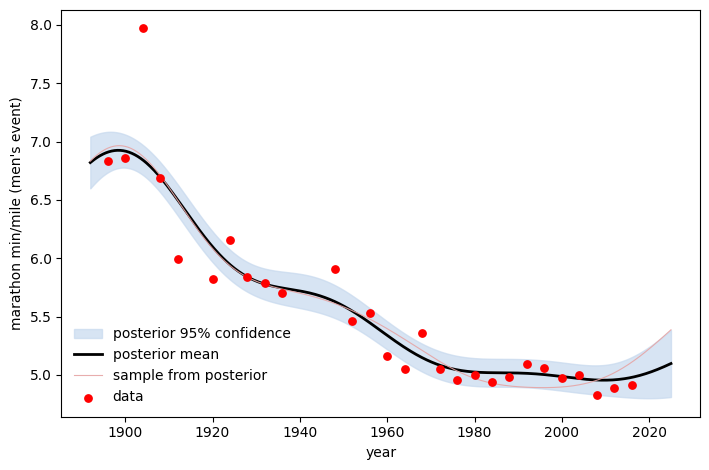

In [ ]:
# Event 1: men's marathon
gp_olympic_event(year, result, kernel, mean, noise, event_name="marathon min/mile (men's event)")


I modeled men's marathon min/mile with an RBF kernel (bandwidth ~12 years) to capture gradual, decade-scale improvements, a constant mean equal to the event's average pace as a neutral baseline, and small noise (sigma^2 ~ 0.003, ~3 s/mile) to reflect year-to-year conditions. The fit looks sensible (it is the same as the one in the demo): the posterior mean follows the long downward trend from ~7 to ~5 min/mile, and most points lie inside the 95% band, which widens near the edges where the model extrapolates. The model correctly flags 1904 St. Louis as an outlier (due to notorious race conditions). Missing Olympics around WWI and WWII produce smooth interpolation and a modest widening of uncertainty across the gaps. Overall, this configuration gives a smooth, believable trend, highlights genuine anomalies, and communicates uncertainty where data are sparse.

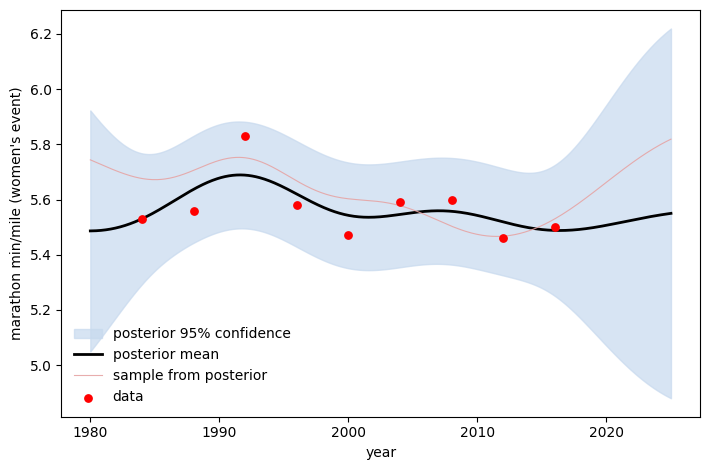

In [ ]:
# Event 2: women's marathon
# need to convert units
mar_w = dat[dat['Event'] == 'Marathon Women']
mar_w = mar_w[mar_w['Medal'] == 'G'].sort_values('Year').reset_index(drop=True)

# unit conversion function (to minutes per mile)
def hhmmss_to_mpm(s):
    parts = [float(p) for p in str(s).split(':')]
    if   len(parts) == 3: sec = parts[0]*3600 + parts[1]*60 + parts[2]
    elif len(parts) == 2: sec = parts[0]*60   + parts[1]
    else:                 sec = float(parts[0])
    return (sec/60.0)/26.2  # minutes per mile

mar_w['Minutes per Mile'] = [round(hhmmss_to_mpm(s), 2) for s in mar_w['Result']]

year_w   = mar_w['Year'].to_numpy()
result_w = mar_w['Minutes per Mile'].to_numpy()

# redefine bandwidth for this one
h = 7 # here I lowered it from 18 to 7
noise = 0.02
kernel = lambda a, b: K_fun(np.asarray(a, float), np.asarray(b, float), h=h)
mean = lambda x: mu_fun(np.asarray(x, float), mu=float(np.mean(result_w)))

# and then I can use my function again
gp_olympic_event(year_w, result_w, kernel, mean, noise, event_name="marathon min/mile (women's event)")



Women's marathon (gold times, 1984-2020): I used the same GP form as the demo with an RBF kernel but a smaller bandwidth (h=7) so the curve can bend a bit more with the sparse data; the mean is a constant set to the event's average minutes-per-mile; the noise was set a little higher (~0.02) than men to reflect the visibly larger point-to-point variability. The plot looks sensible (again similar trend as the one in the demo): the posterior mean rises slightly from 1984 to early 90s, then trends gently down and roughly flattens in the 2000s / 2010s; the 95% band is much wider than for men because there are (unfortunately) very few observations, and it's widest at the edges (classic GP uncertainty when extrapolating). No year stands out as a strong “1904-style” outlier. The point around 1990 is relatively high but all points are plausibly inside the band. There is no WWII gap here (the event begins in 1984), so the main gap effect is just the small sample size. The 95% band widens at the far right because we're at the edge with few nearby observations, so the GP is extrapolating and its predictive variance grows as it falls back toward the prior.

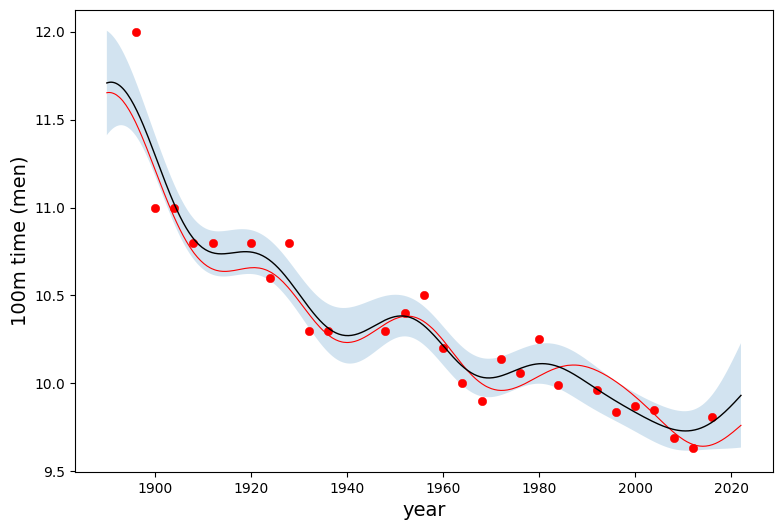

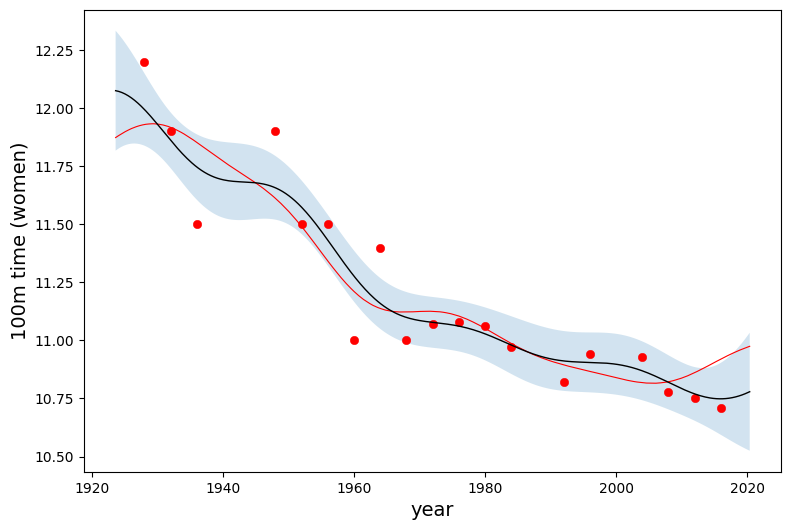

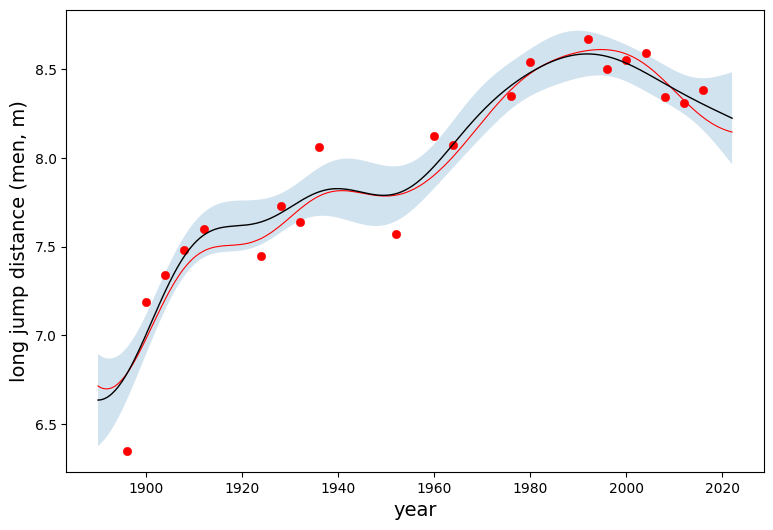

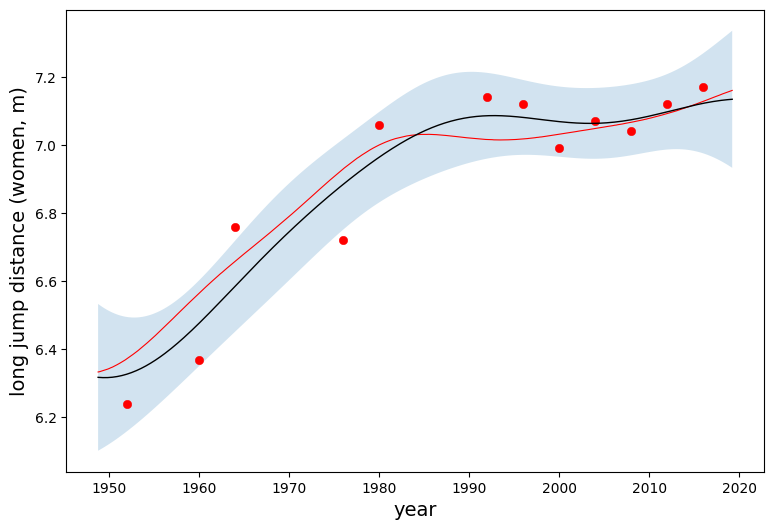

In [ ]:
# define a helper for time string to seconds (works for "mm:ss.xx", "ss.xx", or numeric)
def time_to_seconds(s):
    parts = [float(p) for p in str(s).split(':')]
    if   len(parts) == 3:
        return parts[0]*3600 + parts[1]*60 + parts[2]
    elif len(parts) == 2:
        return parts[0]*60 + parts[1]
    else:
        return float(parts[0])

# one shot plot all the remaining 4 events that I want to plot. Chose 100M men and women and long jump men and women
targets = [
    ("100M Men",    "100m time (men)",    time_to_seconds),
    ("100M Women",  "100m time (women)",  time_to_seconds),
    ("Long Jump Men",   "long jump distance (men, m)",   float),
    ("Long Jump Women", "long jump distance (women, m)", float),
]

for ev, ylab, conv in targets:
    df = dat[(dat["Event"] == ev) & (dat["Medal"] == "G")] \
            .sort_values("Year").reset_index(drop=True)

    # convert results
    yvals = np.array([conv(v) for v in df["Result"]], float)
    xvals = df["Year"].to_numpy()

    if "100m" in ylab.lower():
        h = 12.0   # new value of h
        noise = 0.01
    else:  # long jump
        h = 14.0
        noise = 0.01

    kernel = lambda a, b, h=h: K_fun(np.asarray(a, float), np.asarray(b, float), h=h)
    mean   = lambda x, m=float(np.mean(yvals)): mu_fun(np.asarray(x, float), mu=m)

    gp_olympic_event(xvals, yvals, kernel, mean, noise, ylab)


**100m men**

I use the same GP as before with an RBF kernel and bandwidth h = 12
years to capture slow, multi-year changes in sprint performance; a constant mean is set to the event's average time, and I set the observation noise to sigma^2 = 0.01 (~ 0.1 s SD), which matches typical variability across Olympic finals. The posterior mean tracks the century-long improvement from ~12 s toward ~9.8/9.9 s, with small waves that reflect eras: the mid 40s wartime gap, a sharp dip around 1968 (the 1968 Olympics in Mexico City were held ~2,300 m above sea level. Thinner air lowers drag, which provided an advantage in events requiring short bursts of energy like this one, so 100 m times there were unusually fast), and then steady declines through the Usain Bolt (his dominance between 2008 and 2016 kept times very low in that period). No single point overwhelms the fit, though 1900/1904 are noticeably high and 1968 is notably low—both flagged by sitting near the edge of, or just outside, the 95% band. Overall the kernel/mean/noise choices produce a smooth, plausible trend with uncertainty that grows sensibly at the edges.

**100m women**

I used the same RBF kernel as the men (h=12), a constant mean set to the event's average time, and a small noise level (0.01s^2). The posterior mean shows a smooth, steady improvement from ~12.2 s to ~10.7 s with only mild wiggles; the fit looks reasonable and tracks the points well. No single year looks wildly atypical, despite a few early results sitting above the trend. The confidence band is tight through the dense mid-century region and widens at the very beginning and end where we have fewer games.

**Long jump men**

Kernel RBF with a slightly broader length scale (h = 14) to capture the long gradual progression. Mean is constant at the average winning distance. Noise is 0.01 m^2. The posterior mean shows rapid gains up to the late 1960s, a high plateau through the 1980s to 2000s (near 8.5 m+), then a small softening more recently. The curve looks credible and matches the visible step-change era and later plateau. Uncertainty is modest where data are dense and widens toward the edges.

**Long jump women**

Kernel RBF (h=14), constant mean at the average distance, noise 0.01 m^2. The posterior mean shows steady improvement from the 1950s through the early 1990s. The fit quality seems good, the model captures the big rise and later stabilization without chasing noise. As expected, the band is widest in the early years and at the far right where data are sparse, and narrowest over the middle.

## Problem 3: Double descent! (20 points)

<a href="https://skitheworld.com/2018/12/wurtele-twins-appointed-order-canada/"><img src="https://raw.githubusercontent.com/YData123/sds365-fa25/main/assignments/assn2/double.jpg" width="200" align="left" style="margin:20px 30px 20px 5px"></a>


In this problem you will explore the "double descent" phenomenon that was recently
discovered as a key principle underlying the performance of deep neural networks.
The problem setup is a "random features" version of a 2-layer neural network. The weights in the first layer are random and fixed, and the weights in the second layer are estimated from data. As we increase the number of neurons in the hidden layer, the dimension $p$ of model increases. It's helpful to define the ratio $\gamma = p/n$ of variables to sample points. If $\gamma < 1$ then we want to use the OLS estimator, and if $\gamma > 1$ we want to use the minimum norm estimator.
<br>

Your mission (should you choose to accept it), is

1. Implement a function `OLS_or_minimum_norm` that computes the least squares solution when $\gamma < 1$, and the minimum norm solution when $\gamma > 1$. (When $\gamma=1$ the estimator does not, in general, exist.)
1. Run the main code we give you to average over many trials, and to compute and plot the estimated risk for a range of values of $\gamma$.
1. Next, extend the starter code so that you compute (estimates of) the squared-bias and variance of the models. To do this, note that you'll need access to the true regression function, which is provided. You may want to refer to the demo code for smoothing kernels as an example.
1. Using your new code, extend the plotting function we provide so that you plot
the squared-bias, variance, and risk together on the same plot.
1. Finally, comment on the results, describing why it might make sense that the squared bias, variance, and risk have the given shapes that they do.
1. Show that in the overparameterized regime $\gamma > 1$, as $\lambda \to 0$, the ridge regression estimator converges to the minimum norm estimator.


By doing this exercise you will solidify your understanding of the meaning of bias and variance, and also gain a better understanding of the "double descent" phenomenon for overparameterized neural networks,
and their striking resistance to overfitting.

We're available in OH to help with any issues you run into!

If you have any interest in background reading on this topic (not expected or required), we recommend Hastie et al., ["Surprises in high-dimensional ridgeless least squares regression"](https://www.stat.cmu.edu/~ryantibs/papers/ridgeless.pdf).



In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

### Problem 3.1

Implement the function `OLS_or_minimum_norm` that computes the OLS solution for $\gamma < 1$, and the minimum norm solution for $\gamma > 1$.

In [ ]:
def OLS_or_minimum_norm(X, y):
    ## Your code here
    X = np.asarray(X, float)
    y = np.asarray(y, float).reshape(-1)
    n, p = X.shape

    if p < n:                     # computes OLS
        return np.linalg.solve(X.T @ X, X.T @ y)
    elif p > n:                   # computes minimum-norm
        return X.T @ np.linalg.solve(X @ X.T, y)
    else:                         # in case p == n
        return np.linalg.pinv(X) @ y

In [ ]:
# A plotting function we provide. No need to change this, although you can if you'd like.

def plot_double_descent_risk(gammas, risk, sigma):
    gammas = np.round(gammas, 2)
    fig, ax = plt.subplots(figsize=(10,6))
    tick_pos = np.zeros(len(gammas))
    for i in np.arange(len(gammas)):
        if gammas[i] <= 1:
            tick_pos[i] = gammas[i] * 10
        else:
            tick_pos[i] = gammas[i] + 9
    ax.axvline(x=tick_pos[np.array(gammas)==1][0], linestyle='dashed', color='gray')
    ax.axhline(y=sigma**2, linestyle='dashed', color='gray')
    ax.scatter(tick_pos, risk, color='salmon')
    ax.plot(tick_pos, risk, color='gray', linewidth=.5)

    tickgam = [gam for gam in gammas if (gam > .05 and gam <= .9) or gam >= 2 or gam == 1]
    ticks = [tick_pos[j] for j in np.arange(len(tick_pos)) if gammas[j] in tickgam]
    ax.xaxis.set_ticks(ticks)
    ax.xaxis.set_ticklabels(tickgam)

    plt.xlabel(r'$\gamma = \frac{p}{n}$', fontsize=18)
    _ = plt.ylabel('Risk', fontsize=18)

### Data setup

The following cell sets up our data. The inputs $X$ are
random Gaussian vectors of dimension $d=10$. Then, we map these
using a neural network with fixed, Gaussian weights, to get random features
corresponding to $p^* = 150$ hidden neurons. The second layer
coefficients are $\beta^* \in {\mathbb R}^{p^*}$, which are fixed.
This defines the true model.


In [ ]:
# just execute this cell, after you define the function above.

np.random.seed(123456)

sigma = 1
d = 10
p_star = 150
signal_size = 5

W_star = (1/np.sqrt(d)) * np.random.randn(d, p_star)
beta_star = np.arange(p_star)
beta_star = signal_size * beta_star / np.sqrt(np.sum(beta_star**2))

N = 10000
X = np.random.randn(N, d)

# f_star is the true regression function, for computing the squared bias
f_star = np.dot(np.tanh(np.dot(X, W_star)), beta_star)
noise = sigma * np.random.randn(N)
y = f_star + noise
yf = np.concatenate((y.reshape(N,1), f_star.reshape(N,1)), axis=1)

### Train a sequence of models for different values of $\gamma$

Next, we train a sequence of models for different values of $\gamma$, always
fixing the sample size at $n=200$, but varying the dimension $p = \gamma n$.
When $p < p^*$ we just take the first $p$ features in the true model.
When $p > p^*$ we add $p-p^*$ neurons to the hidden layer, with their
own random weights.

In the code below, we loop over the different values of $\gamma$,
and for each $\gamma$ we run $100$ trials, each time generating
a new training set of size $n=200$. The model (either OLS or minimum norm) is then computed, the MSE is computed, and finally the risk is estimated by averaging over all $100$ trials.


In [ ]:
trials = 100
n = 200

gammas = list(np.arange(.1, 1, .1)) + [.92, .94, 1, 1.1, 1.2, 1.4, 1.6] + list(np.arange(2, 11, 1))
gammas = [.01, .05] + gammas
risk = []
for gamma in gammas:
    err = []
    p = int(n * gamma)
    if gamma == 1:
        risk.append(np.inf)
        continue
    W = (1/np.sqrt(d)) * np.random.randn(d, p)
    W[:,:min(p, p_star)] = W_star[:,:min(p, p_star)]
    for i in np.arange(trials):
        X_train, X_test, yf_train, yf_test = train_test_split(X, yf, train_size=n, test_size=1000)
        H_train = np.tanh(np.dot(X_train, W))
        H_test = np.tanh(np.dot(X_test, W))
        beta_hat = OLS_or_minimum_norm(H_train, yf_train[:,0])
        yhat_test = H_test @ beta_hat
        err.append(np.mean((yhat_test - yf_test[:,0])**2))
    print('gamma=%.2f  p=%d  n=%d  risk=%.3f' % (gamma, p, n, np.mean(err)))
    risk.append(np.mean(err))


gamma=0.01  p=2  n=200  risk=7.373
gamma=0.05  p=10  n=200  risk=4.146
gamma=0.10  p=20  n=200  risk=2.294
gamma=0.20  p=40  n=200  risk=2.099
gamma=0.30  p=60  n=200  risk=2.267
gamma=0.40  p=80  n=200  risk=2.534
gamma=0.50  p=100  n=200  risk=3.011
gamma=0.60  p=120  n=200  risk=3.573
gamma=0.70  p=140  n=200  risk=4.443
gamma=0.80  p=160  n=200  risk=6.885
gamma=0.90  p=180  n=200  risk=15.773
gamma=0.92  p=184  n=200  risk=20.500
gamma=0.94  p=188  n=200  risk=31.661
gamma=1.10  p=220  n=200  risk=24.179
gamma=1.20  p=240  n=200  risk=14.097
gamma=1.40  p=280  n=200  risk=8.089
gamma=1.60  p=320  n=200  risk=6.543
gamma=2.00  p=400  n=200  risk=5.301
gamma=3.00  p=600  n=200  risk=4.073
gamma=4.00  p=800  n=200  risk=3.658
gamma=5.00  p=1000  n=200  risk=3.430
gamma=6.00  p=1200  n=200  risk=3.309
gamma=7.00  p=1400  n=200  risk=3.135
gamma=8.00  p=1600  n=200  risk=3.190
gamma=9.00  p=1800  n=200  risk=3.056
gamma=10.00  p=2000  n=200  risk=3.062


### Plot the risk

At this point, you can plot the risk by just evaluating the cell below.
This should reveal the "double descent" behavior.


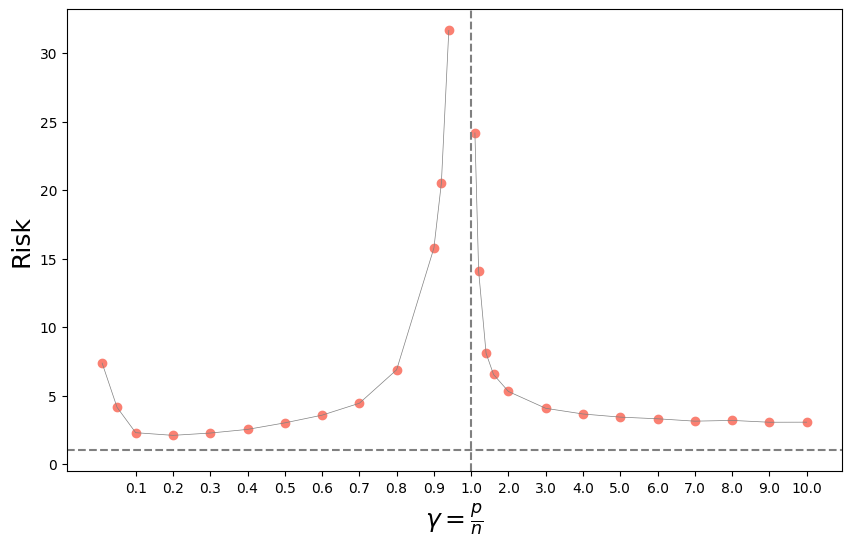

In [ ]:
# Just evaluate the next line
plot_double_descent_risk(gammas, risk, sigma)

### Problem 3.2

Comment on the results. Explain why the risk plot does or does not make sense
in each regime: The underparameterized regime $\gamma < 1$, and the overparameterized
regime $\gamma > 1$. Is the curve "U-shaped" in the underparameterized regime? Why or why not?
What about in the overparameterized regime? You will be able to give better answers to these questions when you estimate the bias and variance below.


**Comments**

In the underparameterized region ($\gamma < p/n$), the risk is the classical U-shaped curve (as discussed in lectures).  With a very small p, the model is too simple, so we get large bias and high risk.  As p increases, the bias drops and the risk falls.  However, when $\gamma$ approaches 1, the least-squares fit becomes bad, coefficients go up to fit noise, variance also goes up, and the risk significantly increases again. In the interpolation threshold ($\gamma \approx p/n$), the OLS effectively becomes singular, the estimator interpolate noise and there is a spike in risk. At $\gamma=1$ the OLS solution is not well-defined. In the overparameterized region ($\gamma>1$), using the minimum-norm interpolator acts like implicit regularization. The fit spreads across many directions, variance drops quickly while bias stays small, so test risk descends again and flattens near the noise level $\sigma^2$. So, overall, we get a U-shape for $\gamma < 1$, a spike at $\gamma\approx1$, and a second descent for $\gamma>1$, which is the what we call the double-descent curve. It is driven by the bias-variance tradeoff and instability at the interpolation threshold.

### Problem 3.3

Now, modify the above code so that you can estimate both the squared bias and the
variance of the estimator. Before you do this, you may want to revisit the kernel smoothing demo from class, where we computed the squared bias, variance, and risk. You'll need the true function, which is provided in the variable `yf`.  You should not have to write a lot of code, but can compute the bias and variance after you store the predicted values on the test data for each trial.

Plot the results, by plotting both the squared bias, the variance, and the risk for the sequence of gammas. To do this you will have to modify the plotting function appropriately, but this again involves minimal changes. When you obtain your final plot, comment
on the shape of the bias and variance curves, as above for Problem 3.2.


In [ ]:
trials = 100
n = 200

gammas = list(np.arange(.1, 1, .1)) + [.92, .94, 1, 1.1, 1.2, 1.4, 1.6] + list(np.arange(2, 11, 1))
risk   = []
bias2  = []
varc   = []

for gamma in gammas:
    p = int(n * gamma)
    if gamma == 1:
        risk.append(np.inf); bias2.append(np.nan); varc.append(np.nan)
        continue

    W = (1/np.sqrt(d)) * np.random.randn(d, p)
    W[:, :min(p, p_star)] = W_star[:, :min(p, p_star)]

    # fixed test set for this gamma (so variance across trials is meaningful)
    X_pool, X_test, yf_pool, yf_test = train_test_split(X, yf, test_size=1000, random_state=0)
    H_test = np.tanh(X_test @ W)
    f_test = yf_test[:, 1]
    y_test = yf_test[:, 0]

    preds = []
    errs  = []
    for _ in range(trials):
        # resample a training set each trial from the pool
        idx = np.random.choice(X_pool.shape[0], size=n, replace=False)
        X_train = X_pool[idx]
        yf_train = yf_pool[idx]

        H_train  = np.tanh(X_train @ W)
        beta_hat = OLS_or_minimum_norm(H_train, yf_train[:, 0])

        yhat_test = H_test @ beta_hat
        preds.append(yhat_test)
        errs.append(np.mean((yhat_test - y_test)**2))

    preds = np.stack(preds, axis=0)
    mean_pred = preds.mean(axis=0)
    bias2.append(np.mean((mean_pred - f_test)**2))
    varc.append(np.mean(np.var(preds, axis=0, ddof=1)))
    risk.append(float(np.mean(errs)))

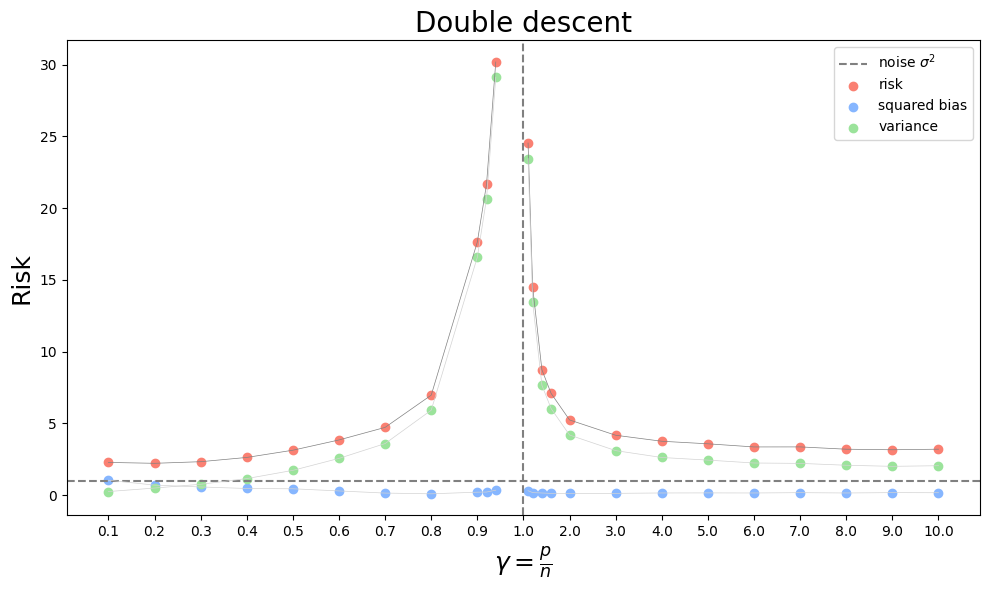

In [ ]:
def plot_double_descent_bvr(gammas, risk, bias2, var, sigma):

    g = np.round(np.asarray(gammas, float), 2)
    r = np.asarray(risk,  float)
    b = np.asarray(bias2, float)
    v = np.asarray(var,   float)

    tick_pos = np.where(g <= 1, g*10, g+9)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.axvline(x=tick_pos[np.where(g==1)[0][0]], linestyle='dashed', color='gray')
    ax.axhline(y=sigma**2, linestyle='dashed', color='gray', label=r'noise $\sigma^2$')

    ax.plot(tick_pos, r, color='gray', linewidth=.5)
    ax.plot(tick_pos, b, color='lightgray', linewidth=.5)
    ax.plot(tick_pos, v, color='lightgray', linewidth=.5)

    ax.scatter(tick_pos, r, color='salmon',  label='risk')
    ax.scatter(tick_pos, b, color='#86b6ff', label='squared bias')
    ax.scatter(tick_pos, v, color='#9be39b', label='variance')

    tickgam = [gam for gam in g if (gam>.05 and gam<=.9) or gam>=2 or gam==1]
    ticks   = [tick_pos[j] for j in range(len(tick_pos)) if g[j] in tickgam]
    ax.set_xticks(ticks); ax.set_xticklabels(tickgam)

    ax.set_xlabel(r'$\gamma = \frac{p}{n}$', fontsize=18)
    ax.set_ylabel('Risk', fontsize=18)
    ax.set_title('Double descent', fontsize=20)
    ax.legend()
    plt.tight_layout(); plt.show()

plot_double_descent_bvr(gammas, risk, bias2, varc, sigma)

In the underparameterized region ($\gamma < 1$), the risk first falls as p grows because the model's bias$^2$ shrinks; with very small p the model is too simple and risk is high. As $\gamma$ approaches 1 from the left, the model becomes badly scaled, the least-squares fit amplifies noise, variance increases, and risk rises again. At the interpolation threshold ($\gamma\approx1$) the OLS solution is unstable/singular: coefficients go up to fit training noise, producing the sharp risk spike. But, as we add parameters, in the overparameterized region on the right of the plot ($\gamma>1$), the minimum-norm interpolator acts as implicit $L_2$ regularization: variance collapses quickly while bias$^2$ stays small, so the test risk drops again and levels off near the noise floor $\sigma^2$ (dashed line). This is what we call the double-descent phenomenon. Overall we see: U-shape for $\gamma < 1$, a spike at $\gamma\approx1$, and a second descent for $\gamma>1$, again the double-descent curve driven by shrinking bias at first, variance explosion at interpolation, and variance control via the min-norm solution afterward.

### Problem 3.4

In class, we discussed the interpretation of the minimum-norm estimator $ \hat{\beta}_{\text{mn}} $. Geometrically, we can describe $ \hat{\beta}_{\text{mn}} $ as the orthogonal projection of the zero vector in $ \mathbb{R}^p $ onto the $ (p-1) $-dimensional hyperplane $ \{ \beta : X\beta = Y \} $.  

This can also be viewed as "ridgeless" regression. In ridge regression, we minimize the objective function
$$
\| Y - X\beta  \|_2^2 + \lambda \| \beta \|_2^2,
$$
which has the closed-form solution
$$
\hat{\beta}_{\lambda} = (X^T X + \lambda I)^{-1} X^T Y.
$$

In the overparameterized regime where $ p > n $, it can be shown that as $ \lambda \to 0 $, $ \hat{\beta}_{\lambda} $ converges to $ \hat{\beta}_{\text{mn}} $.

Your task is to show that as $ \lambda \to 0 $, the limit of the ridge regression estimator $ \hat{\beta}_{\lambda} $, in the overparameterized regime where $ \gamma > 1 $, is the minimum-norm estimator $ \hat{\beta}_{\text{mn}} $. You may want to use the Woodbury formula for this derivation.


_Hint_:
1. Applying the simplified version of Woodbury formula
$$
(I + UV^T)^{-1} = I - U(I + V^T U)^{-1} V^T.
$$
we can derive the identity:
$$
(X^T X + \lambda I_p)^{-1} X^T = X^T (X X^T + \lambda I_n)^{-1},
$$
2. You might consider using the Woodbury formula twice.



Please refer to handwritten markdown for 3.4 (attached)


